In [ ]:
from pathlib import Path
from glob import glob
import random
import time
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print('PyTorch version', torch.__version__)
print('Torchvision version', torchvision.__version__)
print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version 2.14.0
Torchvision version 0.29.0
Numpy version 2.5.3
Pandas version 3.0.2
CUDA available: False


In [10]:
try:
    from google.colab import drive
    drive.mount('/content/gdrive')
    PROJECT_ROOT = Path('/content/gdrive/MyDrive/CNN_Data')
except ImportError:
    print('Not running in Google Colab; Drive mount skipped.')
    PROJECT_ROOT = Path('.')

Not running in Google Colab; Drive mount skipped.


In [12]:
DATA_ROOT = PROJECT_ROOT / 'data'
TRAIN_ROOT = DATA_ROOT / 'train'
TEST_ROOT = DATA_ROOT / 'test'
TEST2_ROOT = DATA_ROOT / 'test2'   
CHECKPOINT_PATH = PROJECT_ROOT / 'best_efficientnet_b0_scenes.pt'
SEED = 0

def set_random_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_random_seed(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Project root:', PROJECT_ROOT.resolve())
print('Data root:', DATA_ROOT.resolve())
print('Train root:', TRAIN_ROOT.resolve())
print('Using device:', device)

Project root: /Users/benas/Documents/Computer_Vision/The-CNN-Challenge
Data root: /Users/benas/Documents/Computer_Vision/The-CNN-Challenge/data
Train root: /Users/benas/Documents/Computer_Vision/The-CNN-Challenge/data/train
Using device: mps


In [13]:
IMG_SIZE = 224
BATCH_SIZE = 32
VAL_FRACTION = 0.20
NUM_WORKERS = 2 if device.type == 'cuda' else 0 

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0), ratio=(0.8, 1.25)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Two ImageFolder views of the same training folder so train and validation get different transforms.
train_view = datasets.ImageFolder(TRAIN_ROOT, transform=train_transform)
val_view = datasets.ImageFolder(TRAIN_ROOT, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_ROOT, transform=eval_transform)

class_names = train_view.classes
num_classes = len(class_names)
assert test_dataset.classes == class_names, 'train/test class folders do not match'

# Stratified split: every class keeps the same proportion in train and validation.
all_targets = np.array(train_view.targets)
train_idx, val_idx = train_test_split(
    np.arange(len(all_targets)), test_size=VAL_FRACTION,
    stratify=all_targets, random_state=SEED,
)
train_dataset = Subset(train_view, train_idx)
val_dataset = Subset(val_view, val_idx)

pin = device.type == 'cuda'
g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g,
                          num_workers=NUM_WORKERS, pin_memory=pin, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)

print(f'Classes ({num_classes}): {class_names}')
print(f'Train: {len(train_dataset)} | Validation: {len(val_dataset)} | Test: {len(test_dataset)}')

Classes (16): ['Bedroom', 'Coast', 'Flower', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']
Train: 1920 | Validation: 480 | Test: 400


Batch shape: torch.Size([32, 3, 224, 224]) torch.Size([32])


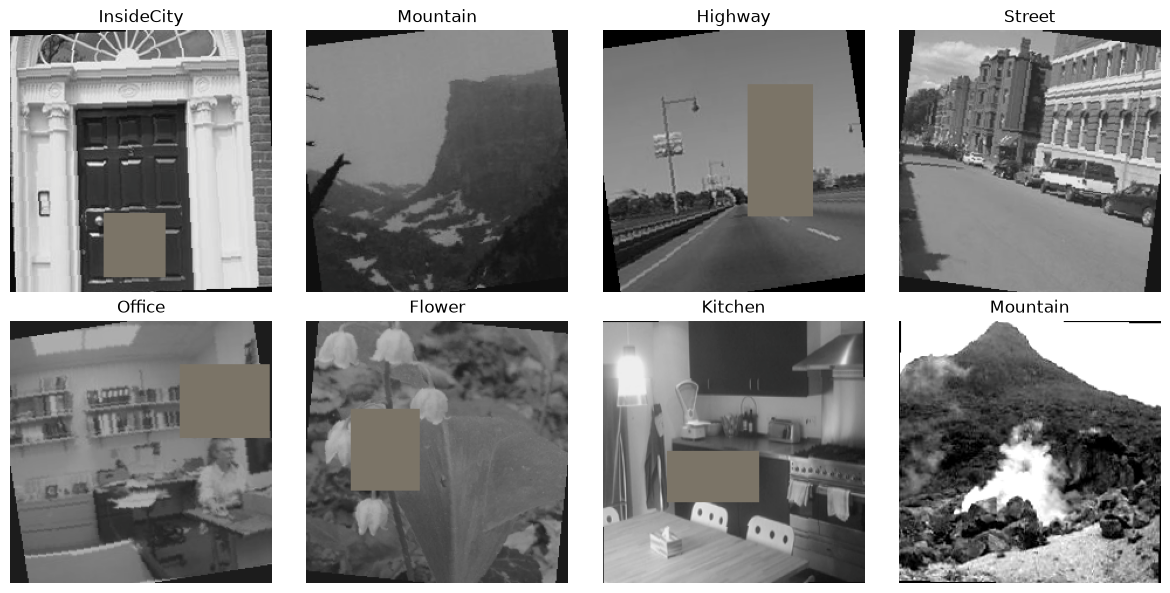

In [14]:
images, labels = next(iter(train_loader))
print('Batch shape:', images.shape, labels.shape)

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, image, label in zip(axes.flat, images[:8], labels[:8]):
    ax.imshow((image * std + mean).clamp(0, 1).permute(1, 2, 0))
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [15]:
class SceneClassifier(nn.Module):
    def __init__(self, num_classes, dropout=0.3, pretrained=True):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        base_model = models.efficientnet_b0(weights=weights)
        self.features = base_model.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        enet_out_size = 1280
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(enet_out_size, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

import os, ssl
try:
    import certifi
    os.environ.setdefault('SSL_CERT_FILE', certifi.where())
    ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
except ImportError:
    pass

model = SceneClassifier(num_classes=num_classes)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')
with torch.no_grad():
    print('Output shape for one batch:', model(images[:4]).shape)

Trainable parameters: 4,028,044
Output shape for one batch: torch.Size([4, 16])


In [16]:
@torch.inference_mode()
def evaluate(model, loader, device, tta=False, return_preds=False):
    # Loss/accuracy on a loader. With tta=True, logits are averaged with the horizontally-flipped image.
    model.eval()
    criterion = nn.CrossEntropyLoss()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        if tta:
            logits = (logits + model(torch.flip(images, dims=[3]))) / 2
        running_loss += criterion(logits, labels).item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        if return_preds:
            all_preds.append(preds.cpu()); all_labels.append(labels.cpu())
    if return_preds:
        return running_loss / total, correct / total, torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()
    return running_loss / total, correct / total


def make_optimizer(model, backbone_lr, head_lr, weight_decay):
    # AdamW with a smaller LR for pretrained filters and a larger LR for the freshly initialized head.
    return optim.AdamW([
        {'params': model.features.parameters(), 'lr': backbone_lr},
        {'params': model.classifier.parameters(), 'lr': head_lr},
    ], weight_decay=weight_decay)


def warmup_cosine(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + np.cos(np.pi * progress))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def train_model(model, train_loader, val_loader, optimizer, scheduler, num_epochs, device,
                label_smoothing=0.1, patience=6):
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    model.to(device)
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc, best_epoch, epochs_no_improve = 0.0, 0, 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    start = time.time()

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, correct, seen = 0.0, 0, 0
        for images, labels in tqdm(train_loader, desc=f'Training loop {epoch}/{num_epochs}', leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()
            scheduler.step()                       # per-step schedule
            running_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            seen += labels.size(0)

        train_loss, train_acc = running_loss / seen, correct / seen
        val_loss, val_acc = evaluate(model, val_loader, device)
        for k, v in zip(history, (train_loss, train_acc, val_loss, val_acc, optimizer.param_groups[0]['lr'])):
            history[k].append(v)

        flag = ''
        if val_acc > best_val_acc:
            best_val_acc, best_epoch, epochs_no_improve = val_acc, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
            flag = '  <- best'
        else:
            epochs_no_improve += 1

        print(f'Epoch {epoch:02d}/{num_epochs} | train loss {train_loss:.4f} acc {train_acc:.4f} | '
              f'val loss {val_loss:.4f} acc {val_acc:.4f} | {time.time() - start:.0f}s{flag}')
        if epochs_no_improve >= patience:
            print(f'Early stopping: no validation improvement for {patience} epochs.')
            break

    model.load_state_dict(best_state)
    print(f'Best validation accuracy: {best_val_acc:.4f} (epoch {best_epoch})')
    return model, history

In [17]:
NUM_EPOCHS = 20
BACKBONE_LR = 3e-4
HEAD_LR = 3e-3
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 1

set_random_seed(SEED)
model = SceneClassifier(num_classes=num_classes, dropout=0.3).to(device)
optimizer = make_optimizer(model, BACKBONE_LR, HEAD_LR, WEIGHT_DECAY)
steps_per_epoch = len(train_loader)
scheduler = warmup_cosine(optimizer, WARMUP_EPOCHS * steps_per_epoch, NUM_EPOCHS * steps_per_epoch)

model, history = train_model(model, train_loader, val_loader, optimizer, scheduler,
                             num_epochs=NUM_EPOCHS, device=device, label_smoothing=0.1, patience=6)

torch.save({'model_state': model.state_dict(), 'class_names': class_names,
            'img_size': IMG_SIZE, 'arch': 'efficientnet_b0'}, CHECKPOINT_PATH)
print('Saved checkpoint to', CHECKPOINT_PATH)

Epoch 01/20 | train loss 1.9532 acc 0.5057 | val loss 0.4198 acc 0.8792 | 61s  <- best


Epoch 02/20 | train loss 0.9332 acc 0.8740 | val loss 0.3994 acc 0.9104 | 114s  <- best


Epoch 03/20 | train loss 0.8215 acc 0.9219 | val loss 0.3173 acc 0.9250 | 166s  <- best


Epoch 04/20 | train loss 0.7442 acc 0.9542 | val loss 0.3319 acc 0.9167 | 218s


Epoch 05/20 | train loss 0.7236 acc 0.9630 | val loss 0.3532 acc 0.9104 | 271s


...

Epoch 16/20 | train loss 0.6167 acc 0.9932 | val loss 0.2772 acc 0.9479 | 852s  <- best


Epoch 17/20 | train loss 0.6114 acc 0.9974 | val loss 0.2734 acc 0.9437 | 905s


Epoch 18/20 | train loss 0.6117 acc 0.9964 | val loss 0.2701 acc 0.9479 | 957s


Epoch 19/20 | train loss 0.6084 acc 0.9974 | val loss 0.2726 acc 0.9437 | 1010s


Epoch 20/20 | train loss 0.6119 acc 0.9964 | val loss 0.2671 acc 0.9521 | 1062s  <- best
Best validation accuracy: 0.9521 (epoch 20)
Saved checkpoint to best_efficientnet_b0_scenes.pt


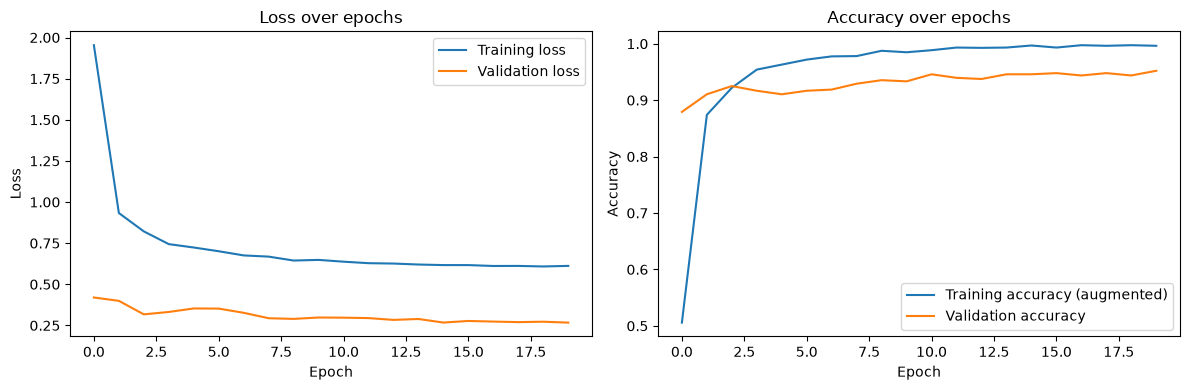

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='Training loss')
ax1.plot(history['val_loss'], label='Validation loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss over epochs'); ax1.legend()
ax2.plot(history['train_acc'], label='Training accuracy (augmented)')
ax2.plot(history['val_acc'], label='Validation accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy over epochs'); ax2.legend()
plt.tight_layout()
plt.show()

Validation accuracy: 0.9521 | with flip-TTA: 0.9458
              precision    recall  f1-score   support

     Bedroom      0.964     0.900     0.931        30
       Coast      0.857     1.000     0.923        30
      Flower      1.000     1.000     1.000        30
      Forest      1.000     0.933     0.966        30
     Highway      0.938     1.000     0.968        30
  Industrial      0.906     0.967     0.935        30
  InsideCity      0.963     0.867     0.912        30
     Kitchen      0.906     0.967     0.935        30
  LivingRoom      0.933     0.933     0.933        30
    Mountain      1.000     1.000     1.000        30
      Office      1.000     1.000     1.000        30
 OpenCountry      0.923     0.800     0.857        30
       Store      0.933     0.933     0.933        30
      Street      0.968     1.000     0.984        30
      Suburb      1.000     1.000     1.000        30
TallBuilding      0.966     0.933     0.949        30

    accuracy                

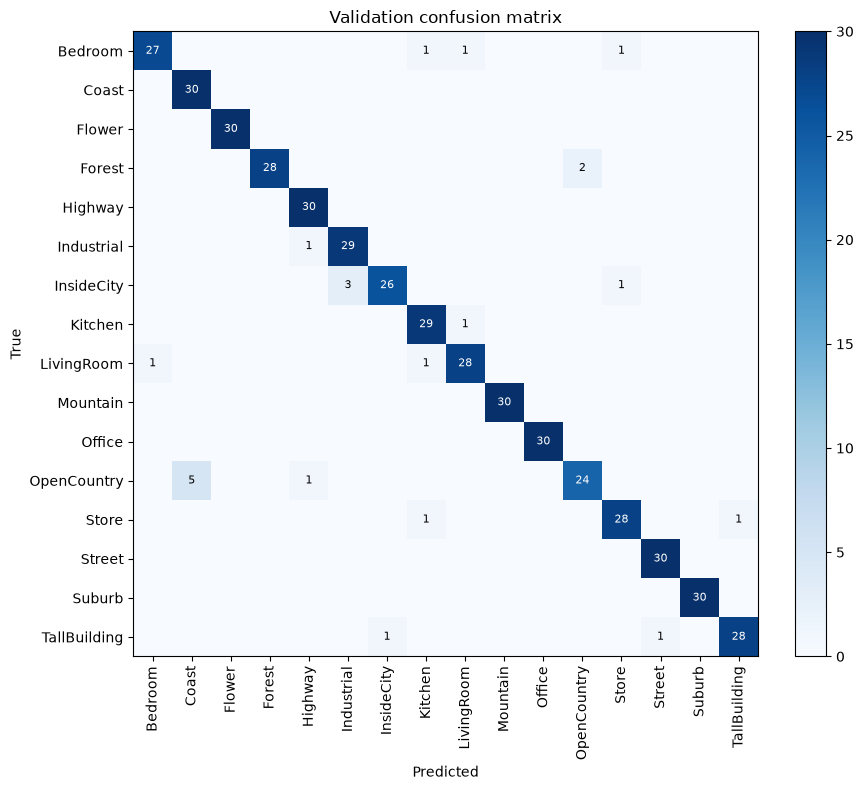

In [19]:
val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, device, return_preds=True)
val_loss_tta, val_acc_tta = evaluate(model, val_loader, device, tta=True)
print(f'Validation accuracy: {val_acc:.4f} | with flip-TTA: {val_acc_tta:.4f}')
print(classification_report(val_labels, val_preds, target_names=class_names, digits=3))

cm = confusion_matrix(val_labels, val_preds)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(num_classes)); ax.set_xticklabels(class_names, rotation=90)
ax.set_yticks(range(num_classes)); ax.set_yticklabels(class_names)
for i in range(num_classes):
    for j in range(num_classes):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=8)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Validation confusion matrix')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

In [20]:
test_loss, test_acc = evaluate(model, test_loader, device)
test_loss_tta, test_acc_tta = evaluate(model, test_loader, device, tta=True)
print(f'Final test loss: {test_loss:.4f}')
print(f'Final test accuracy: {test_acc:.4f}')
print(f'Final test accuracy with flip-TTA: {test_acc_tta:.4f}')

Final test loss: 0.2617
Final test accuracy: 0.9525
Final test accuracy with flip-TTA: 0.9550


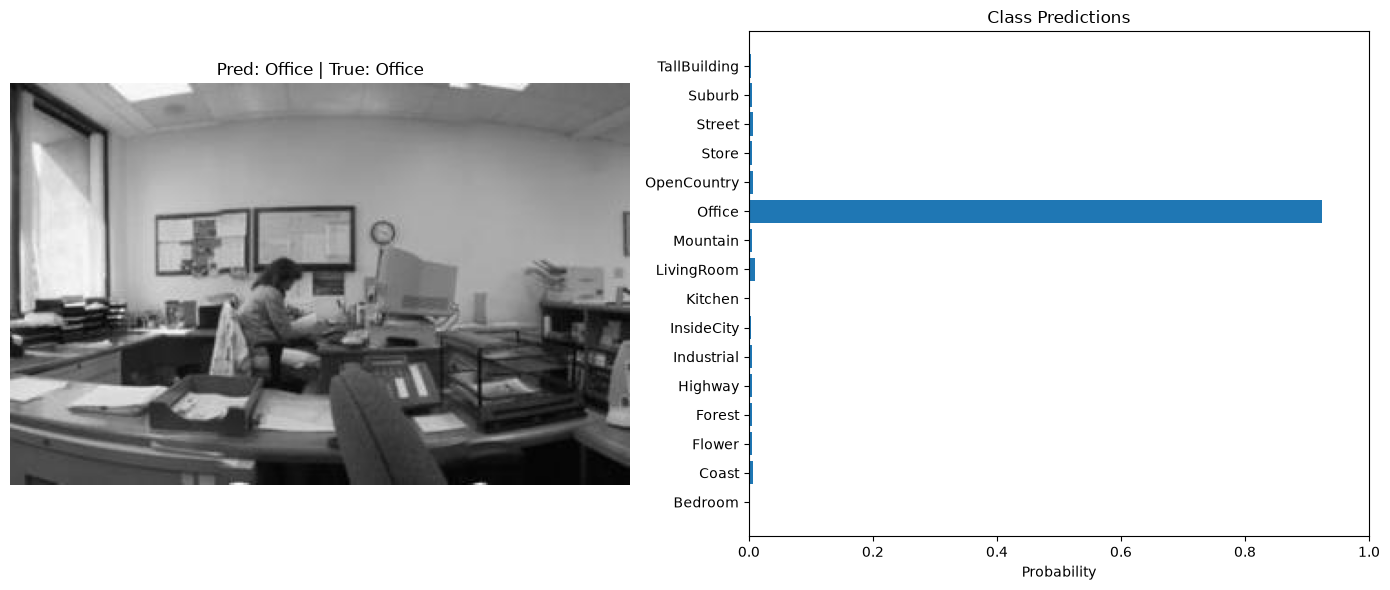

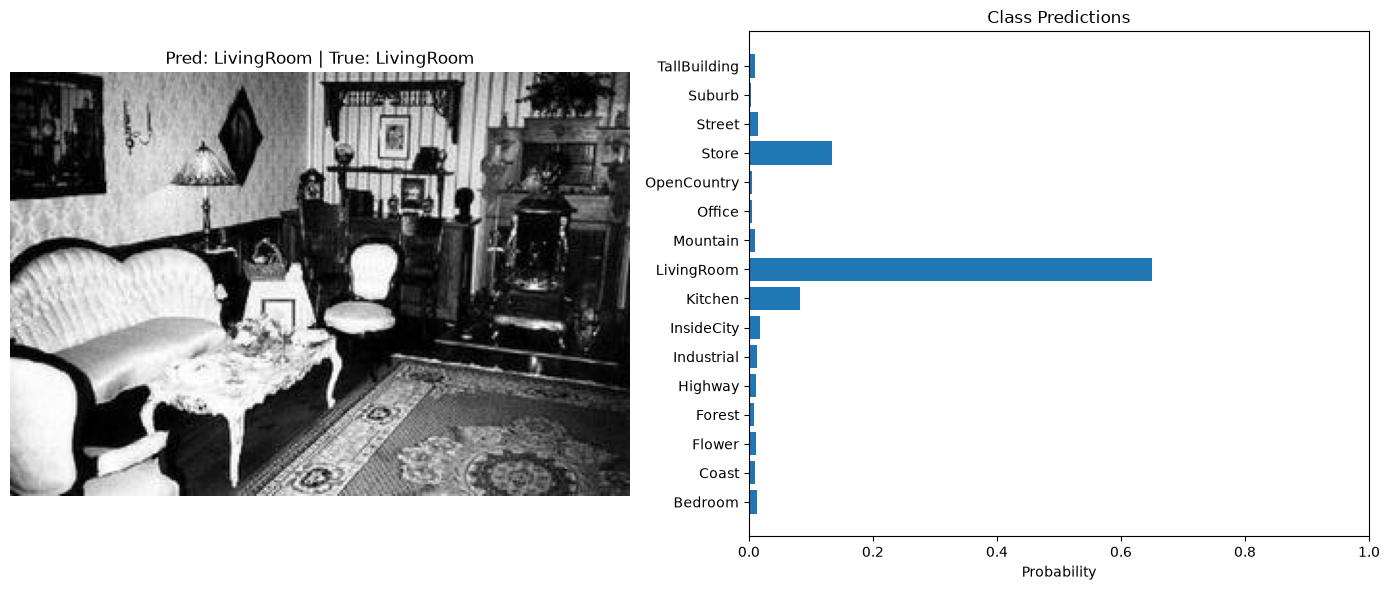

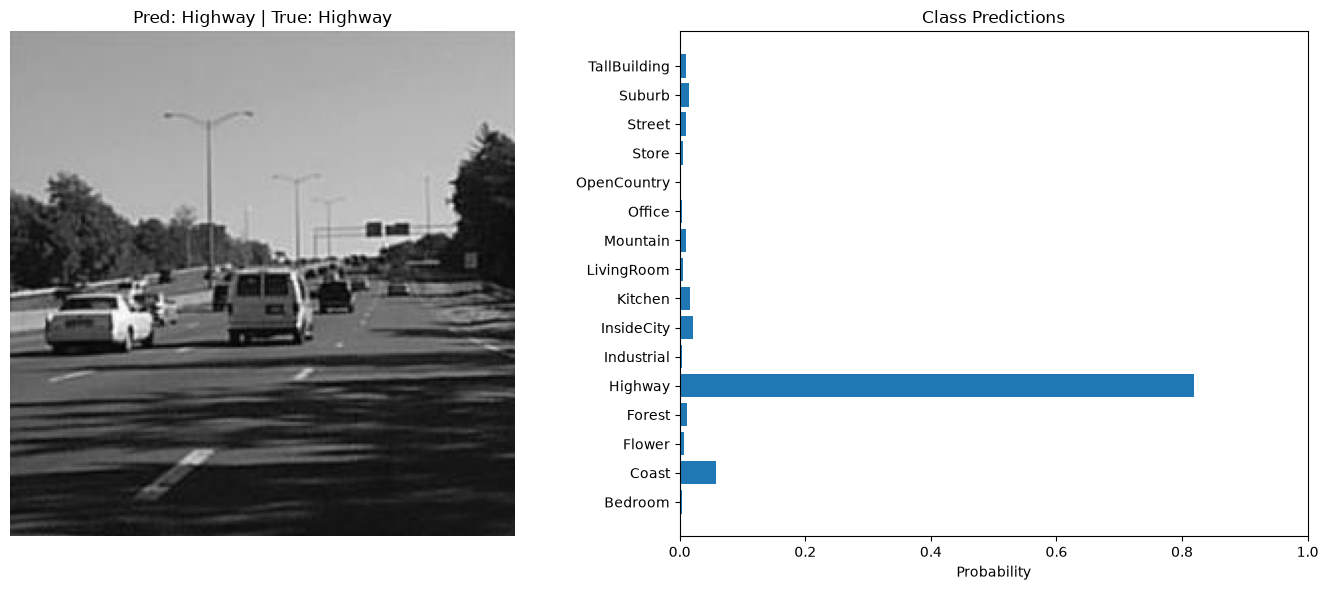

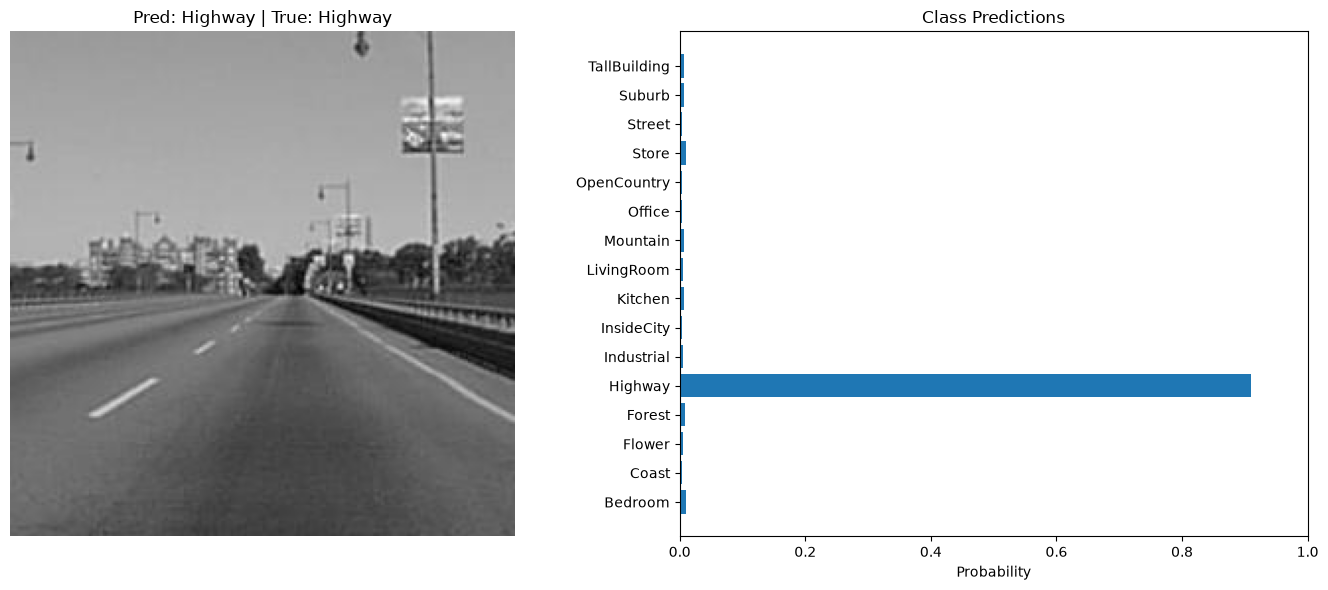

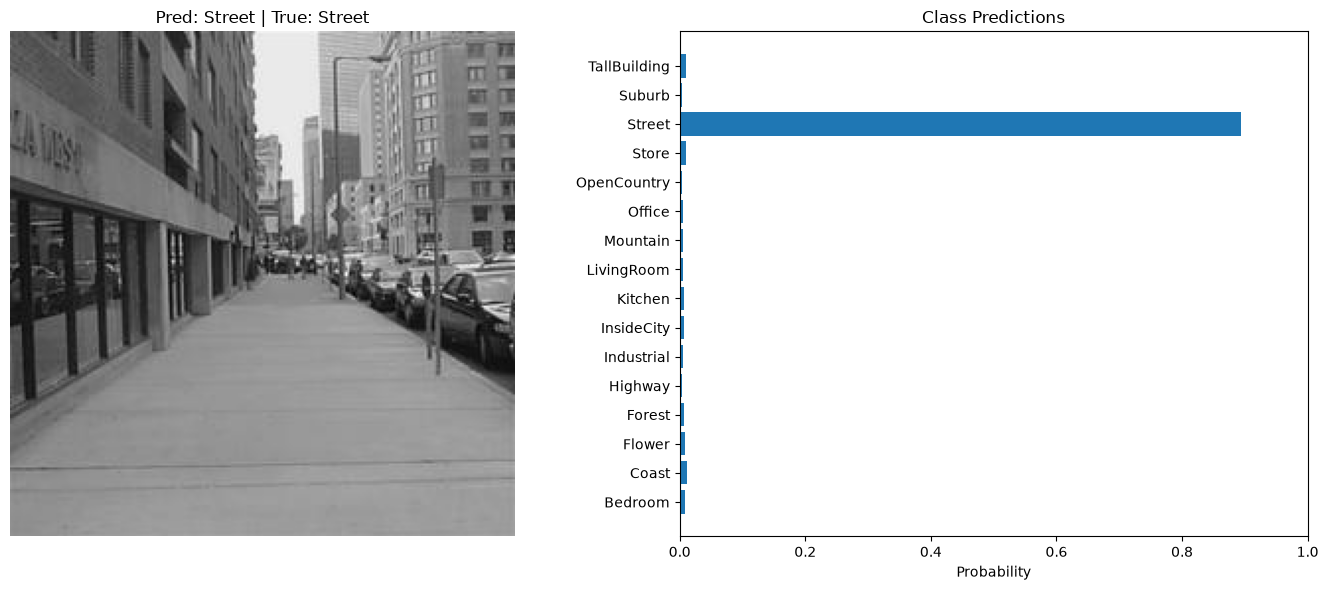

In [21]:
def preprocess_image(image_path, transform):
    image = Image.open(image_path).convert('RGB')
    return image, transform(image).unsqueeze(0)

def predict(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    return probabilities.cpu().numpy().flatten()

def visualize_predictions(original_image, probabilities, class_names, true_label=None):
    fig, axarr = plt.subplots(1, 2, figsize=(14, 6))
    axarr[0].imshow(original_image, cmap='gray' if original_image.mode == 'L' else None)
    axarr[0].axis('off')
    pred = class_names[int(np.argmax(probabilities))]
    axarr[0].set_title(f'Pred: {pred}' + (f' | True: {true_label}' if true_label else ''))
    axarr[1].barh(class_names, probabilities)
    axarr[1].set_xlabel('Probability')
    axarr[1].set_title('Class Predictions')
    axarr[1].set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

test_images = sorted(glob(str(TEST_ROOT / '*' / '*.jpg')))
rng = np.random.default_rng(SEED)
for example in rng.choice(test_images, 5, replace=False):
    original_image, image_tensor = preprocess_image(example, eval_transform)
    probabilities = predict(model, image_tensor, device)
    visualize_predictions(original_image, probabilities, class_names, true_label=Path(example).parent.name)

In [ ]:
test2_images = sorted(glob(str(TEST2_ROOT / '*.jpg')), key=lambda p: int(Path(p).stem.split('_')[-1]))
rows = []
for path in tqdm(test2_images, desc='test2'):
    _, image_tensor = preprocess_image(path, eval_transform)
    x = image_tensor.to(device)
    with torch.no_grad():
        model.eval()
        logits = (model(x) + model(torch.flip(x, dims=[3]))) / 2
        probs = torch.softmax(logits, dim=1).cpu().numpy().flatten()
    rows.append({'image': Path(path).name, 'prediction': class_names[int(probs.argmax())], 'confidence': float(probs.max())})

test2_predictions = pd.DataFrame(rows)
test2_predictions.to_csv(PROJECT_ROOT / 'test2_predictions.csv', index=False)
print(test2_predictions['prediction'].value_counts())
test2_predictions.head()